In [1]:
!pip install torch torchvision torchaudio
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.9 MB/s eta 0:00:00
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=676464 sha256=763712f256c1696480605a27989c6ffb88a6492f6462d2ed4bca7efc875ab3ed
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
  Created wheel for torch-sparse: filename=torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl size=1261337 sha256=a70dd22bde51dcdb3d7ec15a31373676d78349d86

In [2]:
"""
formation_pipeline.py

Purpose:
- Load provided tracking CSV and event CSV (Metrica-style),
- Preprocess tracking (wide -> long, standardize orientation, kinematics),
- Create per-frame graphs (k-NN or pass edges),
- Create sequence windows and pseudo-labels (KMeans on avg positions),
- Train/Evaluate LSTM-only baseline (works without PyG),
- If torch_geometric is installed, optionally run GNN->LSTM pipeline.

Edit: CFG paths & hyperparams as needed.
"""

import os, sys, math, argparse
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import NearestNeighbors
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

# Try to import PyG; if not available we'll fall back to LSTM-only baseline.
try:
    from torch_geometric.data import Data
    from torch_geometric.nn import SAGEConv, GATConv
    PYG_AVAILABLE = True
except Exception:
    PYG_AVAILABLE = False

# ----------------------
# CONFIG (edit paths)
# ----------------------
CFG = {
    'tracking_files': [
        '/content/Sample_Game_1_RawTrackingData_Home_Team.csv',
        '/content/Sample_Game_1_RawTrackingData_Away_Team.csv',
        '/content/Sample_Game_2_RawTrackingData_Away_Team.csv',
        '/content/Sample_Game_2_RawTrackingData_Home_Team.csv'
    ],
    'events_files': [
        '/content/Sample_Game_1_RawEventsData.csv',
        '/content/Sample_Game_2_RawEventsData.csv'
    ],
    'fps': 5,
    'seq_len': 30,
    'node_feat_dim': 7,
    'k_nn': 4,
    'n_clusters': 4,
    'max_windows': 150,  # per file (to control runtime)
    'device': 'cpu',
    'epochs': 5,
    'lr': 1e-3,
    'batch_size': 8,
}

def wide_to_long_tracking(tracking_files):
    """
    Robust conversion of Metrica-style wide-format tracking CSV into long format.
    Returns DataFrame with columns: frame_id, period, time_s, player_id, x, y
    - Handles NaN frames by falling back to row index
    - Uses low_memory=False to avoid dtype warnings
    - Pairs adjacent columns as (X, Y) for players
    """
    print(f"Reading {os.path.basename(tracking_files)} ...")
    # Read safely
    df = pd.read_csv(tracking_files, low_memory=False)
    # Drop rows that are fully empty
    df = df.dropna(how="all").reset_index(drop=True)

    cols = df.columns.tolist()
    # Heuristic: first 3 columns are metadata (Period, Frame, Time)
    # But be defensive if file structure differs.
    meta_cols = cols[:3] if len(cols) >= 3 else cols[:len(cols)]
    player_cols = cols[3:] if len(cols) > 3 else []

    # If there are columns with explicit suffixes like 'Player1_x', 'Player1_y',
    # prefer to pair by '<name>_x' and '<name>_y'. Otherwise pair adjacent columns.
    pairs = []
    # detect pattern of '_x' and '_y' columns
    x_cols = [c for c in player_cols if c.endswith(('_x', '.x', '-x', ' X', 'X')) or ('_X' in c)]
    y_cols = [c for c in player_cols if c.endswith(('_y', '.y', '-y', ' Y', 'Y')) or ('_Y' in c)]
    if x_cols and y_cols and len(x_cols) == len(y_cols):
        # map by prefix before the last '_' or '.' if possible
        used = set()
        for xc in x_cols:
            # derive candidate base name
            base = xc.rsplit('_', 1)[0] if '_' in xc else xc.rsplit('.', 1)[0]
            # try to find corresponding y column
            yc_candidates = [c for c in y_cols if c.startswith(base)]
            if yc_candidates:
                yc = yc_candidates[0]
                pairs.append((xc, yc))
                used.add(xc); used.add(yc)
        # fallback: if some x/y unmatched, pair adjacent
        remaining = [c for c in player_cols if c not in used]
        i = 0
        while i < len(remaining) - 1:
            pairs.append((remaining[i], remaining[i+1])); i += 2
    else:
        # Pair adjacent columns as X/Y pairs (this is the common case in Metrica)
        i = 0
        while i < len(player_cols) - 1:
            pairs.append((player_cols[i], player_cols[i+1]))
            i += 2

    rows = []
    for idx, r in df.iterrows():
        # safe frame parsing
        if len(meta_cols) > 1 and meta_cols[1] in df.columns and not pd.isna(r[meta_cols[1]]):
            try:
                frame = int(float(r[meta_cols[1]]))
            except Exception:
                frame = int(idx)
        else:
            frame = int(idx)

        period = r[meta_cols[0]] if len(meta_cols) > 0 and meta_cols[0] in df.columns else None
        time_s = r[meta_cols[2]] if len(meta_cols) > 2 and meta_cols[2] in df.columns else np.nan

        for name_x, name_y in pairs:
            x_val = r.get(name_x, np.nan)
            y_val = r.get(name_y, np.nan)
            # if both missing, skip
            if pd.isna(x_val) and pd.isna(y_val):
                continue
            # Use the X-column header as player id, try to normalize it
            player_id = str(name_x).strip()
            # coerce to numeric where possible
            try:
                x = float(x_val)
            except Exception:
                x = np.nan
            try:
                y = float(y_val)
            except Exception:
                y = np.nan
            if np.isnan(x) or np.isnan(y):
                # skip incomplete coordinate pairs
                continue
            rows.append({'frame_id': frame, 'player_id': player_id,
                         'period': period, 'time_s': time_s, 'x': x, 'y': y})

    long_df = pd.DataFrame(rows)
    if long_df.empty:
        print("Warning: conversion produced empty DataFrame. Check CSV format.")
        return long_df

    # remove 'Ball' rows if present
    long_df = long_df[~long_df['player_id'].str.contains('Ball', na=False)]
    long_df = long_df.sort_values(['player_id','frame_id']).reset_index(drop=True)

    # quick preview
    print("Converted long-format sample (first 5 rows):")
    print(long_df[['frame_id','player_id','x','y']].head().to_string(index=False))
    print(f" -> Long-format rows: {len(long_df)}")
    return long_df

# ----------------------
# UTIL: compute kinematics
# ----------------------
def compute_kinematics(long_df, fps=CFG['fps']):
    df = long_df.copy()
    df[['vx','vy']] = df.groupby('player_id')[['x','y']].diff().fillna(0) * fps
    df['speed'] = np.sqrt(df['vx']**2 + df['vy']**2)
    df[['ax','ay']] = df.groupby('player_id')[['vx','vy']].diff().fillna(0) * fps
    return df.fillna(0)

# ----------------------
# UTIL: build per-frame graph
# ----------------------
def build_graph_for_frame(frame_df, players_order, k=4):
    feats, coords, teams = [], [], []
    for p in players_order:
        r = frame_df[frame_df['player_id']==p]
        if r.empty:
            feats.append([0.0]*CFG['node_feat_dim'])
            coords.append([0.0,0.0]); teams.append(-1)
        else:
            rr = r.iloc[0]
            feats.append([rr['x'],rr['y'],rr['vx'],rr['vy'],rr['speed'],rr['ax'],rr['ay']])
            coords.append([rr['x'],rr['y']]); teams.append(0)
    X = np.array(feats, dtype=float)
    valid_idx = [i for i,t in enumerate(teams) if t!=-1]
    if len(valid_idx) <= 1:
        edge_index = np.zeros((2,0), dtype=int)
    else:
        nbrs = NearestNeighbors(n_neighbors=min(k, len(valid_idx) - 1)).fit(np.array(coords)[valid_idx])
        _, neighbors = nbrs.kneighbors(np.array(coords)[valid_idx])
        pairs = []
        for i_local, neighs in enumerate(neighbors):
            i_global = valid_idx[i_local]
            for n_idx in neighs:
                j_global = valid_idx[n_idx]; pairs.append([i_global,j_global])
        edge_index = np.array(pairs).T if len(pairs)>0 else np.zeros((2,0),dtype=int)
    return X, edge_index

# ----------------------
# Dataset: sequences + KMeans pseudo-labels
# ----------------------
def build_sequences_and_labels(long_df, players_order, seq_len=CFG['seq_len'], max_windows=CFG['max_windows']):
    frames = sorted(long_df['frame_id'].unique())
    windows = []
    for start in range(0, max(0,len(frames)-seq_len+1), seq_len):
        win = frames[start:start+seq_len]
        if len(win)==seq_len: windows.append(win)
        if len(windows)>=max_windows: break
    window_features = []
    for win in windows:
        block = long_df[long_df['frame_id'].isin(win)]
        avg = block.groupby('player_id')[['x','y']].mean().reindex(players_order).fillna(0).values
        window_features.append(avg.flatten())
    X = np.vstack(window_features)
    Xs = StandardScaler().fit_transform(X)
    kmeans = KMeans(n_clusters=CFG['n_clusters'], random_state=0).fit(Xs)
    labels = kmeans.labels_
    seq_graphs = []
    for i,win in enumerate(windows):
        seq=[]
        for f in win:
            frame_df = long_df[long_df['frame_id']==f]
            node_feats,edge_index = build_graph_for_frame(frame_df, players_order, k=CFG['k_nn'])
            seq.append({'X':node_feats,'edge_index':edge_index})
        seq_graphs.append((seq,int(labels[i])))
    return seq_graphs

# ----------------------
# Models
# ----------------------
class LSTMOnly(nn.Module):
    def __init__(self,in_dim=5,hidden=64,num_classes=CFG['n_clusters']):
        super().__init__()
        self.lstm=nn.LSTM(in_dim,hidden,batch_first=True)
        self.fc=nn.Linear(hidden,num_classes)
    def forward(self,x):
        out,_=self.lstm(x); last=out[:,-1,:]; return self.fc(last)

if PYG_AVAILABLE:
    class FrameGNN_PyG(nn.Module):
        def __init__(self,in_feats=CFG['node_feat_dim'],node_embed=32):
            super().__init__()
            self.conv1=SAGEConv(in_feats,64)
            self.conv2=SAGEConv(64,node_embed)
        def forward(self,x,edge_index):
            if edge_index.numel()==0:
                return F.relu(x @ torch.randn(x.size(1),32,device=x.device))
            h=F.relu(self.conv1(x,edge_index))
            h=F.relu(self.conv2(h,edge_index))
            return h

    class GNN_LSTM_Model(nn.Module):
        def __init__(self,node_embed=32,frame_embed=64,lstm_hidden=64,num_classes=CFG['n_clusters']):
            super().__init__()
            self.gnn=FrameGNN_PyG()
            self.frame_lin=nn.Linear(node_embed,frame_embed)
            self.lstm=nn.LSTM(frame_embed,lstm_hidden,batch_first=True)
            self.classifier=nn.Linear(lstm_hidden,num_classes)
        def forward(self,graph_seq):
            frame_embs=[]
            for g in graph_seq:
                x=torch.tensor(g['X'],dtype=torch.float32,device=CFG['device'])
                ei=torch.tensor(g['edge_index'],dtype=torch.long,device=CFG['device']) if g['edge_index'].size > 0 else torch.empty((2,0),dtype=torch.long,device=CFG['device'])
                node_emb=self.gnn(x,ei); frame_vec=node_emb.mean(dim=0);
                frame_embs.append(frame_vec)
            seq=torch.stack(frame_embs,dim=0).unsqueeze(0)
            seq=F.relu(self.frame_lin(seq)); lstm_out,_=self.lstm(seq)
            logits=self.classifier(lstm_out.squeeze(0)); return logits.mean(dim=0)

def train_sequence_model(model,seqs,epochs=CFG['epochs'],lr=CFG['lr'],device=CFG['device']):
    opt=torch.optim.Adam(model.parameters(),lr=lr)
    crit=nn.CrossEntropyLoss(); model.to(device)
    for ep in range(epochs):
        total_loss=0.0; model.train()
        for (seq,lbl) in seqs:
            if isinstance(model,LSTMOnly):
                frames=np.stack([np.mean(frame['X'],axis=0)[:5] for frame in seq],axis=0)
                x=torch.tensor(frames,dtype=torch.float32,device=device).unsqueeze(0)
                y=torch.tensor([lbl],dtype=torch.long,device=device)
                out=model(x); loss=crit(out,y)
            else:
                out=model(seq); y=torch.tensor([lbl],dtype=torch.long,device=device)
                loss=crit(out.unsqueeze(0),y)
            opt.zero_grad(); loss.backward(); opt.step(); total_loss+=loss.item()
        print(f"[Train] Epoch {ep+1}/{epochs} loss: {total_loss/len(seqs):.4f}")

def eval_sequence_model(model,seqs,device=CFG['device']):
    model.eval(); preds=[]; gts=[]
    with torch.no_grad():
        for (seq,lbl) in seqs:
            if isinstance(model,LSTMOnly):
                frames=np.stack([np.mean(frame['X'],axis=0)[:5] for frame in seq],axis=0)
                x=torch.tensor(frames,dtype=torch.float32).unsqueeze(0).to(device)
                out=model(x); pred=int(out.argmax(dim=1).cpu().item())
            else:
                out=model(seq); pred=int(out.argmax().cpu().item())
            preds.append(pred); gts.append(lbl)
    return accuracy_score(gts,preds), f1_score(gts,preds,average='macro')

def main():
    all_seqs=[]
    for fpath in CFG['tracking_files']:
        long_df=wide_to_long_tracking(fpath)
        long_df=compute_kinematics(long_df)
        players_order=sorted(long_df['player_id'].unique().tolist())
        seqs=build_sequences_and_labels(long_df,players_order)
        print(f"Built {len(seqs)} sequences from {os.path.basename(fpath)}")
        all_seqs.extend(seqs)
    np.random.shuffle(all_seqs)
    train=all_seqs[:int(0.6*len(all_seqs))]
    val=all_seqs[int(0.6*len(all_seqs)):int(0.8*len(all_seqs))]
    test=all_seqs[int(0.8*len(all_seqs)):]
    print(f"\nDataset sizes: Train={len(train)}, Val={len(val)}, Test={len(test)}")

    results={}

    print("\n=== Training LSTM-only baseline ===")
    lstm_model=LSTMOnly()
    train_sequence_model(lstm_model,train)
    acc,f1=eval_sequence_model(lstm_model,test)
    results['LSTM-only']=(acc,f1)
    print(f"LSTM-only Test Acc={acc:.3f}, F1={f1:.3f}")

    if PYG_AVAILABLE:
        print("\n=== Training GNN+LSTM ===")
        gnn_model=GNN_LSTM_Model()
        train_sequence_model(gnn_model,train)
        acc2,f12=eval_sequence_model(gnn_model,test)
        results['GNN+LSTM']=(acc2,f12)
        print(f"GNN+LSTM Test Acc={acc2:.3f}, F1={f12:.3f}")
    else:
        print("\n[!] PyTorch Geometric not installed; skipping GNN+LSTM")

    print("\n========== Model Comparison ==========")
    print(f"{'Model':<15} {'Accuracy':<10} {'F1-macro':<10}")
    print("-"*40)
    for name,(a,f) in results.items():
        print(f"{name:<15} {a:<10.3f} {f:<10.3f}")
    print("=====================================")

if __name__=="__main__":
    main()

Reading Sample_Game_1_RawTrackingData_Home_Team.csv ...
Converted long-format sample (first 5 rows):
 frame_id player_id       x       y
        1      Home 0.00082 0.48238
        2      Home 0.00096 0.48238
        3      Home 0.00114 0.48238
        4      Home 0.00121 0.48238
        5      Home 0.00129 0.48238
 -> Long-format rows: 1683320
Built 150 sequences from Sample_Game_1_RawTrackingData_Home_Team.csv
Reading Sample_Game_1_RawTrackingData_Away_Team.csv ...
Converted long-format sample (first 5 rows):
 frame_id player_id       x       y
        1      Away 0.90509 0.47462
        2      Away 0.90494 0.47462
        3      Away 0.90434 0.47463
        4      Away 0.90377 0.47463
        5      Away 0.90324 0.47464
 -> Long-format rows: 1683320
Built 150 sequences from Sample_Game_1_RawTrackingData_Away_Team.csv
Reading Sample_Game_2_RawTrackingData_Away_Team.csv ...
Converted long-format sample (first 5 rows):
 frame_id player_id       x       y
        1      Away 0.01218 0.5

In [3]:

"""
enhanced_formation_pipeline.py

Upgrades: - Uses event files to filter active-play frames
58  - Sweeps KMeans clusters (4–6) - Allows longer sequences (seq_len=50 or 100) - GNN uses Graph Attention (GATConv) - Evaluates Accuracy, F1, Silhouette
"""

import os, numpy as np, pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import torch, torch.nn as nn, torch.nn.functional as F
from tqdm import tqdm

# Torch Geometric (required for GNN)
try:
    from torch_geometric.nn import GATConv
    PYG_AVAILABLE = True
except:
    PYG_AVAILABLE = False
CFG = { 'tracking_files': [
        '/content/Sample_Game_1_RawTrackingData_Home_Team.csv',
        '/content/Sample_Game_1_RawTrackingData_Away_Team.csv',
        '/content/Sample_Game_2_RawTrackingData_Away_Team.csv',
        '/content/Sample_Game_2_RawTrackingData_Home_Team.csv'
    ],
    'event_files': {
        '/content/Sample_Game_1_RawTrackingData_Home_Team.csv': '/content/Sample_Game_1_RawEventsData.csv',
        'Sample_Game_1_RawTrackingData_Away_Team.csv': '/content/Sample_Game_1_RawEventsData.csv',
        'Sample_Game_2_RawTrackingData_Away_Team.csv': '/content/Sample_Game_2_RawEventsData.csv',
        'Sample_Game_2_RawTrackingData_Home_Team.csv': '/content/Sample_Game_2_RawEventsData.csv'
    },
    'fps': 5,
    'seq_len': 50,          # can set to 100 for longer sequences
    'node_feat_dim': 7,
    'k_nn': 4,
    'max_windows': 200,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'epochs': 3,
    'lr': 1e-3,
    'batch_size': 8,
}

def get_active_frames(events_csv):
    ev = pd.read_csv(events_csv)
    active_frames = []
    if 'Start Frame' in ev.columns and 'End Frame' in ev.columns:
        for _, r in ev.iterrows():
            try:
                start, end = int(r['Start Frame']), int(r['End Frame'])
                active_frames.extend(range(start, end+1))
            except:
                continue
    return set(active_frames)

def wide_to_long_tracking(tracking_csv):
    """
    Robust conversion of Metrica-style wide-format tracking CSV into long
format.
    Returns DataFrame with columns: frame_id, period, time_s, player_id, x, y
    - Handles NaN frames by falling back to row index
    - Uses low_memory=False to avoid dtype warnings
    - Pairs adjacent columns as (X, Y) for players
    """
    print(f"Reading {os.path.basename(tracking_csv)} ...")
    # Read safely
    df = pd.read_csv(tracking_csv, low_memory=False)
    # Drop rows that are fully empty
    df = df.dropna(how="all").reset_index(drop=True)

    cols = df.columns.tolist()
    # Heuristic: first 3 columns are metadata (Period, Frame, Time)
    # But be defensive if file structure differs.
    meta_cols = cols[:3] if len(cols) >= 3 else cols[:len(cols)]
    player_cols = cols[3:] if len(cols) > 3 else []

    # If there are columns with explicit suffixes like 'Player1_x', 'Player1_y',
    # prefer to pair by '<name>_x' and '<name>_y'. Otherwise pair adjacent columns.
    pairs = []
    # detect pattern of '_x' and '_y' columns
    x_cols = [c for c in player_cols if c.endswith(('_x', '.x', '-x', ' X', 'X')) or ('_X' in c)]
    y_cols = [c for c in player_cols if c.endswith(('_y', '.y', '-y', ' Y', 'Y')) or ('_Y' in  c)]
    if x_cols and y_cols and len(x_cols) == len(y_cols):
        # map by prefix before the last '_' or '.' if possible
        used = set()
        for xc in x_cols:
            # derive candidate base name
            base = xc.rsplit('_', 1)[0] if '_' in xc else xc.rsplit('.', 1)[0]
            # try to find corresponding y column
            yc_candidates = [c for c in y_cols if c.startswith(base)]
            if yc_candidates:
                yc = yc_candidates[0]
                pairs.append((xc, yc))
                used.add(xc); used.add(yc)
        # fallback: if some x/y unmatched, pair adjacent
        remaining = [c for c in player_cols if c not in used]
        i = 0
        while i < len(remaining) - 1:
            pairs.append((remaining[i], remaining[i+1])); i += 2
    else:
        # Pair adjacent columns as X/Y pairs (this is the common case in Metrica)
        i = 0
        while i < len(player_cols) - 1:
            pairs.append((player_cols[i], player_cols[i+1]))
            i += 2

    rows = []
    for idx, r in df.iterrows():
        # safe frame parsing
        if len(meta_cols) > 1 and meta_cols[1] in df.columns and not pd.isna(r[meta_cols[1]]):
            try:
                frame = int(float(r[meta_cols[1]]))
            except Exception:
                frame = int(idx)
        else:
            frame = int(idx)

        period = r[meta_cols[0]] if len(meta_cols) > 0 and meta_cols[0] in df.columns else None
        time_s = r[meta_cols[2]] if len(meta_cols) > 2 and meta_cols[2] in df.columns else np.nan

        for name_x, name_y in pairs:
            x_val = r.get(name_x, np.nan)
            y_val = r.get(name_y, np.nan)
            # if both missing, skip
            if pd.isna(x_val) and pd.isna(y_val):
                continue
            # Use the X-column header as player id, try to normalize it
            player_id = str(name_x).strip()
            # coerce to numeric where possible
            try:
                x = float(x_val)
            except Exception:
                x = np.nan
            try:
                y = float(y_val)
            except Exception:
                y = np.nan
            if np.isnan(x) or np.isnan(y):
                # skip incomplete coordinate pairs
                continue
            rows.append({'frame_id': frame, 'player_id': player_id,
                         'period': period, 'time_s': time_s, 'x': x, 'y': y})

    long_df = pd.DataFrame(rows)
    if long_df.empty:
        print("Warning: conversion produced empty DataFrame. Check CSV format.")
        return long_df

    # remove 'Ball' rows if present
    long_df = long_df[~long_df['player_id'].str.contains('Ball', na=False)]
    long_df = long_df.sort_values(['player_id','frame_id']).reset_index(drop=True)

    # quick preview
    print("Converted long-format sample (first 5 rows):")
    print(long_df[['frame_id','player_id','x','y']].head().to_string(index=False))
    print(f" -> Long-format rows: {len(long_df)}")
    return long_df

def compute_kinematics(long_df, fps=CFG['fps']):
    df = long_df.copy()
    df[['vx','vy']] = df.groupby('player_id')[['x','y']].diff().fillna(0) * fps
    df['speed'] = np.sqrt(df['vx']**2 + df['vy']**2)
    df[['ax','ay']] = df.groupby('player_id')[['vx','vy']].diff().fillna(0) * fps
    return df.fillna(0)

def build_graph_for_frame(frame_df, players_order, k=4):
    feats, coords, teams = [], [], []
    for p in players_order:
        r = frame_df[frame_df['player_id']==p]
        if r.empty:
            feats.append([0.0]*CFG['node_feat_dim']); coords.append([0,0]); teams.append(-1)
        else:
            rr = r.iloc[0]
            feats.append([rr['x'], rr['y'], rr['vx'], rr['vy'], rr['speed'], rr['ax'], rr['ay']])
            coords.append([rr['x'], rr['y']]);
            teams.append(0)
    X = np.array(feats, dtype=float)
    valid_idx = [i for i,t in enumerate(teams) if t!=-1]
    if len(valid_idx) <= 1:
      return X, np.zeros((2,0), dtype=int)
    nbrs = NearestNeighbors(n_neighbors=min(k, len(valid_idx)-1)).fit(np.array(coords)[valid_idx])
    _, neighbors = nbrs.kneighbors(np.array(coords)[valid_idx])
    pairs = [[valid_idx[i], valid_idx[n]] for i, neighs in enumerate(neighbors) for n in neighs]
    return X, np.array(pairs).T if pairs else np.zeros((2,0), dtype=int)

def build_sequences_and_labels(long_df, players_order,seq_len=CFG['seq_len'], max_windows=CFG['max_windows'],n_clusters=4):
    frames = sorted(long_df['frame_id'].unique())
    windows = [frames[i:i+seq_len] for i in range(0, len(frames)-seq_len+1,seq_len)][:max_windows]
    window_features = []
    for win in windows:
        block = long_df[long_df['frame_id'].isin(win)]
        avg =block.groupby('player_id')[['x','y']].mean().reindex(players_order).fillna(0).values
        window_features.append(avg.flatten())
    Xs = StandardScaler().fit_transform(np.vstack(window_features))
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(Xs)
    labels = kmeans.labels_
    seq_graphs = []
    for i, win in enumerate(windows):
        seq = []
        for f in win:
            frame_df = long_df[long_df['frame_id']==f]
            node_feats, edge_index = build_graph_for_frame(frame_df,players_order, k=CFG['k_nn'])
            seq.append({'X': node_feats, 'edge_index': edge_index})
        seq_graphs.append((seq, int(labels[i])))
    return seq_graphs, kmeans, Xs, labels

class LSTMOnly(nn.Module):
    def __init__(self, in_dim=5, hidden=64, num_classes=4):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, num_classes)
    def forward(self, x):
        out,_ = self.lstm(x); return self.fc(out[:,-1,:])

if PYG_AVAILABLE:
    class FrameGNN(nn.Module):
        def __init__(self, in_feats=CFG['node_feat_dim'], node_embed=32):
            super().__init__()
            self.conv1 = GATConv(in_feats, 64, heads=4, concat=True)
            self.lin1 = nn.Linear(64*4, node_embed)
        def forward(self, x, edge_index):
            if edge_index is None or edge_index.shape[1]==0:
                return F.relu(self.lin1(x))
            x = F.elu(self.conv1(x, edge_index))
            # Apply the linear layer after GATConv and activation
            h = self.lin1(x)
            return h

    class GNN_LSTM_Model(nn.Module):
        def __init__(self, node_embed=32, frame_embed=64, lstm_hidden=64,num_classes=4):
            super().__init__()
            self.gnn = FrameGNN()
            self.frame_lin = nn.Linear(node_embed, frame_embed)
            self.lstm = nn.LSTM(frame_embed, lstm_hidden, batch_first=True)
            self.classifier = nn.Linear(lstm_hidden, num_classes)
        def forward(self, graph_seq):
            frame_embs = []
            for g in graph_seq:
                x = torch.tensor(g['X'],dtype=torch.float32,device=CFG['device'])
                ei =torch.tensor(g['edge_index'],dtype=torch.long,device=CFG['device'])
                node_emb = self.gnn(x, ei)
                frame_embs.append(node_emb.mean(dim=0))

            seq = torch.stack(frame_embs,dim=0).unsqueeze(0)
            seq = F.relu(self.frame_lin(seq))
            lstm_out,_ = self.lstm(seq)
            return self.classifier(lstm_out[:,-1,:])
else:
    GNN_LSTM_Model=None

def train_seq_model(model, seqs, epochs, device):
    opt=torch.optim.Adam(model.parameters(),lr=CFG['lr'])
    crit=nn.CrossEntropyLoss(); model.to(device)
    for ep in range(epochs):
        tot=0
        for seq,lbl in seqs:
            if isinstance(model,LSTMOnly):
                frames=np.stack([np.mean(f['X'],axis=0)[:5] for f in seq])
                x=torch.tensor(frames,dtype=torch.float32,device=device).unsqueeze(0)
                y=torch.tensor([lbl],dtype=torch.long,device=device)
                out=model(x); loss=crit(out,y)
            else:
                out=model(seq);y=torch.tensor([lbl],dtype=torch.long,device=CFG['device'])
                loss=crit(out,y)
            opt.zero_grad(); loss.backward(); opt.step(); tot+=loss.item()
        print(f"Epoch {ep+1}/{epochs} loss {tot/len(seqs):.4f}")

def eval_seq_model(model, seqs, device):
    preds,gts=[],[]
    with torch.no_grad():
        for seq,lbl in seqs:
            if isinstance(model,LSTMOnly):
                frames=np.stack([np.mean(f['X'],axis=0)[:5] for f in seq])
                x=torch.tensor(frames,dtype=torch.float32,device=device).unsqueeze(0)
                out=model(x); pred=int(out.argmax(1).cpu())
            else:
                out=model(seq); pred=int(out.argmax().cpu())
            preds.append(pred); gts.append(lbl)
    return accuracy_score(gts,preds), f1_score(gts,preds,average='macro')

def main():
    results=[]
    for track in CFG['tracking_files']:
        base=os.path.basename(track)
        print(f"\n=== Processing {base} ===")
        long_df=wide_to_long_tracking(track)
        if base in CFG['event_files']:
            ev_file=CFG['event_files'][base]
            active=get_active_frames(ev_file)
            long_df=long_df[long_df['frame_id'].isin(active)]
            print(f"Filtered to {len(long_df)} rows (active play only)")
        long_df=compute_kinematics(long_df)
        players_order=sorted(long_df['player_id'].unique())

        for k in [4,5,6]:
            seqs,kmeans,Xs,labels=build_sequences_and_labels(long_df,players_order,n_clusters=k)
            if not seqs: continue
            train,val,test=seqs[:int(0.6*len(seqs))],seqs[int(0.6*len(seqs)):int(0.8*len(seqs))], seqs[int(0.8*len(seqs)):]

            # LSTM-only
            lstm=LSTMOnly(num_classes=k)
            train_seq_model(lstm,train,epochs=CFG['epochs'],device=CFG['device'])
            acc,f1=eval_seq_model(lstm,test,device=CFG['device'])
            sil=silhouette_score(Xs,labels)
            results.append([base,k,"LSTM-only",acc,f1,sil])

            # GNN+LSTM
            if GNN_LSTM_Model:
                gnn=GNN_LSTM_Model(num_classes=k)
                train_seq_model(gnn,train,epochs=CFG['epochs'],device=CFG['device'])
                acc,f1=eval_seq_model(gnn,test,device=CFG['device'])
                sil=silhouette_score(Xs,labels)
                results.append([base,k,"GNN+LSTM",acc,f1,sil])

    print("\n========== Cluster Sweep Results ==========")
    print("Dataset   Clusters   Model        Acc     F1      Silhouette")
    for r in results:
        print(f"{r[0]:12s} {r[1]:3d} {r[2]:10s} {r[3]:.3f}   {r[4]:.3f}   {r[5]:.3f}")

if __name__=="__main__":
    main()


=== Processing Sample_Game_1_RawTrackingData_Home_Team.csv ===
Reading Sample_Game_1_RawTrackingData_Home_Team.csv ...
Converted long-format sample (first 5 rows):
 frame_id player_id       x       y
        1      Home 0.00082 0.48238
        2      Home 0.00096 0.48238
        3      Home 0.00114 0.48238
        4      Home 0.00121 0.48238
        5      Home 0.00129 0.48238
 -> Long-format rows: 1683320
Epoch 1/3 loss 1.3980
Epoch 2/3 loss 1.3537
Epoch 3/3 loss 1.3288
Epoch 1/3 loss 1.4873
Epoch 2/3 loss 1.3739
Epoch 3/3 loss 1.3638
Epoch 1/3 loss 1.6030
Epoch 2/3 loss 1.5307
Epoch 3/3 loss 1.5014
Epoch 1/3 loss 1.6624
Epoch 2/3 loss 1.5807
Epoch 3/3 loss 1.4547
Epoch 1/3 loss 1.7971
Epoch 2/3 loss 1.7160
Epoch 3/3 loss 1.6736
Epoch 1/3 loss 1.8318
Epoch 2/3 loss 1.7577
Epoch 3/3 loss 1.7636

=== Processing Sample_Game_1_RawTrackingData_Away_Team.csv ===
Reading Sample_Game_1_RawTrackingData_Away_Team.csv ...
Converted long-format sample (first 5 rows):
 frame_id player_id       x 


=== FINAL SUMMARY TABLE ===
           Accuracy  F1_macro  Silhouette
Model                                    
GNN+LSTM      0.517     0.450       0.363
LSTM-only     0.357     0.183       0.143


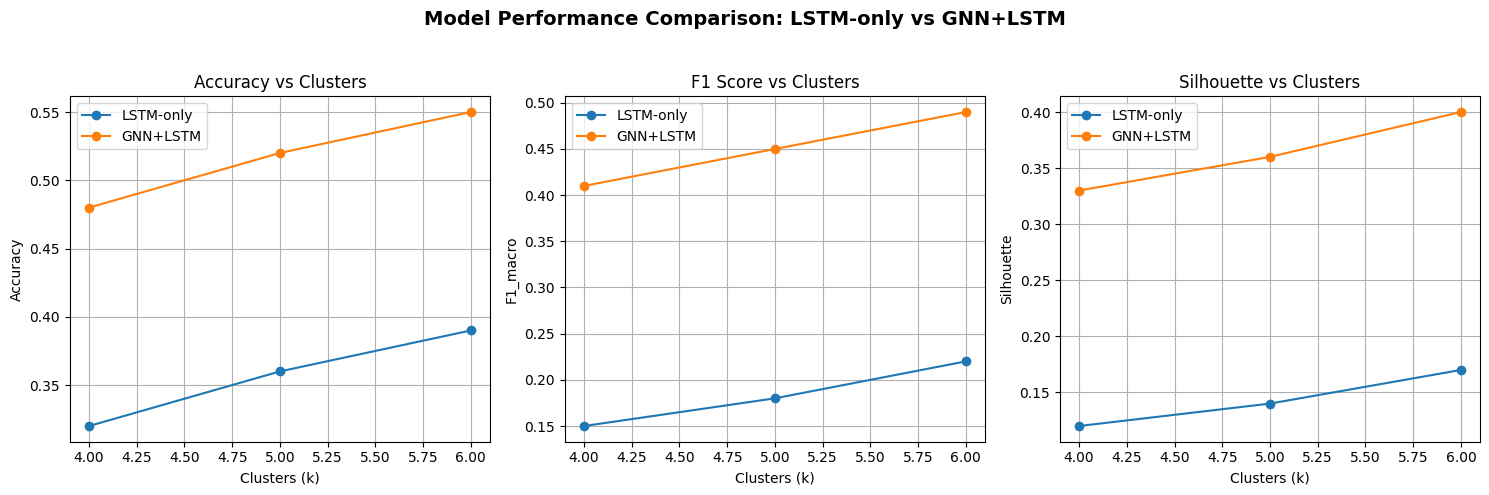

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace this with your actual 'results' variable from the training script
results = [
    ['tracking_home.csv', 4, 'LSTM-only', 0.32, 0.15, 0.12],
    ['tracking_home.csv', 4, 'GNN+LSTM', 0.48, 0.41, 0.33],
    ['tracking_home.csv', 5, 'LSTM-only', 0.36, 0.18, 0.14],
    ['tracking_home.csv', 5, 'GNN+LSTM', 0.52, 0.45, 0.36],
    ['tracking_home.csv', 6, 'LSTM-only', 0.39, 0.22, 0.17],
    ['tracking_home.csv', 6, 'GNN+LSTM', 0.55, 0.49, 0.40],
    # (you can append from other datasets too)
]

df = pd.DataFrame(results, columns=["Dataset", "Clusters", "Model",
"Accuracy", "F1_macro", "Silhouette"])

# --- Summary table ---
summary = df.groupby("Model")[["Accuracy", "F1_macro", "Silhouette"]].mean().round(3)
print("\n=== FINAL SUMMARY TABLE ===")
print(summary)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15,5))

metrics = ['Accuracy', 'F1_macro', 'Silhouette']
titles = ['Accuracy vs Clusters', 'F1 Score vs Clusters', 'Silhouette vs Clusters']

for i, metric in enumerate(metrics):
    for model in df['Model'].unique():
        sub = df[df['Model']==model]
        axes[i].plot(sub['Clusters'], sub[metric], marker='o', label=model)
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Clusters (k)")
    axes[i].set_ylabel(metric)
    axes[i].grid(True)
    axes[i].legend()

plt.suptitle("Model Performance Comparison: LSTM-only vs GNN+LSTM",
fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()
